In [6]:
import numpy as np
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor




ModuleNotFoundError: No module named 'seaborn'

In [9]:
# Raw data


# Clinical Data
df = pl.read_csv("../data/raw/X_train/clinical_train.csv")
df_eval = pl.read_csv("../data/raw/X_test/clinical_test.csv")



In [14]:
df

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,f64,f64,f64,str
"""P132697""","""MSK""",14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…"
"""P132698""","""MSK""",1.0,7.4,2.4,0.1,11.6,42.0,"""46,xx"""
"""P116889""","""MSK""",15.0,3.7,2.1,0.1,14.2,81.0,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…"
"""P132699""","""MSK""",1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…"
"""P132700""","""MSK""",6.0,128.0,9.7,0.9,11.1,195.0,"""46,xx,t(3;9)(p13;q22)[10]/46,x…"
…,…,…,…,…,…,…,…,…
"""P121828""","""VU""",1.0,3.7,2.53,0.53,8.9,499.0,"""46,xy[20]"""
"""P121829""","""VU""",0.0,4.2,2.4,0.22,10.6,49.0,"""46,xy,del(13)(q12q14)[1]/45,x,…"
"""P121830""","""VU""",0.0,1.8,0.55,0.29,9.4,86.0,"""46,xy,del(20)(q11.2q13.1)[4]/4…"


In [12]:
print(df["CYTOGENETICS"].value_counts().top_k(k=5 , by="count"))

shape: (5, 2)
┌──────────────┬───────┐
│ CYTOGENETICS ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ 46,xy[20]    ┆ 432   │
│ null         ┆ 387   │
│ 46,xy        ┆ 276   │
│ 46,xx[20]    ┆ 254   │
│ 46,xx        ┆ 192   │
└──────────────┴───────┘


In [13]:
from scipy.stats import pearsonr

col_int = [col for (col,dtype) in zip(df.columns,df.dtypes)]

In [ ]:
for col in df.columns:
    if df.select(pl.col(col).is_null().sum())[0, 0] > 0:
        print(f"Nom de colonne avec valeurs nulles : {col} , Nombre : {df.select(pl.col(col).is_null().sum())[0, 0]}")

Nom de colonne avec valeurs nulles : BM_BLAST , Nombre : 109
Nom de colonne avec valeurs nulles : WBC , Nombre : 272
Nom de colonne avec valeurs nulles : ANC , Nombre : 193
Nom de colonne avec valeurs nulles : MONOCYTES , Nombre : 601
Nom de colonne avec valeurs nulles : HB , Nombre : 110
Nom de colonne avec valeurs nulles : PLT , Nombre : 124
Nom de colonne avec valeurs nulles : CYTOGENETICS , Nombre : 387


In [18]:
df.filter(pl.col("ID") == "P132697")

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,f64,f64,f64,str
"""P132697""","""MSK""",14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…"


In [19]:
df.filter(pl.col("CYTOGENETICS") == "Normal")

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,f64,f64,f64,f64,f64,f64,str


In [20]:
import re

lst_cyto = df["CYTOGENETICS"].unique().to_list()

for cyto in lst_cyto:
    if cyto is not None:
        reg_expr = r"ins"
        if re.search(reg_expr , cyto , re.IGNORECASE):
            print(cyto)

46,xy,der(7)t(7;20)(q22;q1?),der(19)t(7;19)(q22;q13)ins(19;20)(q13;q12q12),der(20)t(?19;20)(q13;q1?)[15]/47,xy,idem,+1[4]/45,xy,idem,-der(19)t(7;19)[4]/46,xy[5]
42-43,xy,der(4)t(4;12)(q32;q12)del(12)(q14q22),del(5)(q12q35),-7,-12,-13,-14,-16,-17,del(17)(p11),ins(18;7)(q22;?),der(19)t(7;19)(?;13),der(20)t(16;20)(?;q12)t(7;16)(p14;?),-22,ider(22)(q10)t(6;22)(?;q13)t(6;22)(q22;q13),+mar[24]/46,xy[2]
45,xy,del(5)(q14q34),ins(15;7)(q21;q21q31),t(7;15)(q35;q21),-20,der(21)t(20;21)(?;p11)[10]/45,xy,idem,t(1;10;7;3)(q21;q22;q31;q26)[8]/46,xy[2]
46-47,xx,der(5)ins(5;7)(p14;?)t(5;7)(q12;q11)del(7)(q31),-7,del(12)(p12),del(13)(q21),+r(18)(p11q21),+21[cp15]
43~44,xy,-5,add(5)(q11),r(7)(pq?),-9,der(9)del(9)(p21)t(9;19)(q11;q11),-10,der(10)ins(10;?)(p11;?),-16,-18,-19,der(21)t(9;21)(p21;p11),+mar1~5[cp15]/46,xy[5]
45,xy,der(5)t(5;7)(q12;q?),-7,i(8)(q10),del(11)(p12p15),del(13)(q13q21),ins(13;20)(q12;q12q13),dic(16;19)(p12;q12),1-2dmin[cp26]
46,xy,der(1)ins(1;?)(p34:?)[6]/46,xy[16]
44,xy,der(x;5)(q10

In [21]:
import re


def cyto_regex(cyto , reg_expr):
    if cyto is not None:
        if re.search(reg_expr,cyto,re.IGNORECASE):
            return 1
    return 0



df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x : cyto_regex(x,reg_expr=r"del\((\d+.*)\)") , return_dtype=pl.Int64).alias("is_deleted_chr")
)


In [22]:
def is_complex(cyto):
    return 1 if len(re.findall(r"\+|\-|del|t|inv|add|i\(", cyto)) >= 3 else 0

df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x : is_complex(x) , return_dtype=pl.Int64).alias("is_complex_karyo")
)

In [23]:
df.filter(pl.col("is_complex_karyo") == 1)["CYTOGENETICS"]

CYTOGENETICS
str
"""46,xx,del(5)(q12q34),add(5)(q1…"
"""46,xx,del(5)(q14q34)[12]/46,xx…"
"""45,xy,dic(5;17)(q11;p11)order(…"
"""47,xx,-9,+mar1,+mar2[3]/48,xx,…"
"""46,xy,add(1)(p33),del(20)(q12)…"
…
"""45,xy,-7,add(12)(p13),-17,add(…"
"""47~49,xy,+21,+21,+22[cp11]/46,…"
"""44,xx,inv(2)(p25q31),-4,del(5)…"


In [24]:
df.filter(pl.col("is_deleted_chr") == 1)

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo
str,str,f64,f64,f64,f64,f64,f64,str,i64,i64
"""P132697""","""MSK""",14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…",1,0
"""P132699""","""MSK""",1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…",1,0
"""P132704""","""MSK""",14.0,0.8,0.2,0.0,8.8,23.0,"""45,xx,del(5)(q13q33),inc[2]/46…",1,0
"""P106050""","""CCH""",19.0,5.2,2.1,0.1,7.5,5.0,"""46,xx,del(5)(q12q34),add(5)(q1…",1,1
"""P106056""","""CCH""",14.0,18.4,15.8,null,8.5,36.0,"""46,xy,del(9)(q13q33)[4]/46,xy[…",1,0
…,…,…,…,…,…,…,…,…,…,…
"""P121820""","""VU""",4.0,2.89,1.16,0.26,12.9,74.0,"""46,xx,del(20)(q11.2)[17]/46,xx…",1,0
"""P121827""","""VU""",1.5,8.1,2.66,0.45,11.3,40.0,"""44,xx,inv(2)(p25q31),-4,del(5)…",1,1
"""P121829""","""VU""",0.0,4.2,2.4,0.22,10.6,49.0,"""46,xy,del(13)(q12q14)[1]/45,x,…",1,1


In [25]:
df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x : cyto_regex(x,reg_expr=r"iso") , return_dtype=pl.Int64).alias("is_iso")
)

In [26]:
df.filter(pl.col("is_iso") == 1)

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso
str,str,f64,f64,f64,f64,f64,f64,str,i64,i64,i64
"""P132717""","""MSK""",15.0,1.8,0.6,0.1,8.9,51.0,"""46,xx[20]trisomy8onfish""",0,0,1
"""P121101""","""KI""",12.0,3.0,1.0,0.0,8.0,97.0,"""45,xy,del(5)(q13q31),del(7)(p1…",1,1,1
"""P100296""","""PV""",5.0,2.88,1.3,0.23,8.26,34.6,"""47,xx,+19[12]/47,xx,iso(17q),+…",0,1,1
"""P118488""","""ROM""",5.0,2.6,1.3,0.08,9.1,359.0,"""5q-isolata""",0,0,1
"""P118457""","""ROM""",4.0,2.03,0.5,0.4,14.0,183.0,"""46xy[20];evoluzionelam:trisomi…",0,0,1


In [28]:
import re

# Monosomie 7

df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x : cyto_regex(x,reg_expr=r"\-7") , return_dtype=pl.Int64).alias("is_monosomy")
)

In [29]:
df.filter(pl.col("is_monosomy") == 1)

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso,is_monosomy
str,str,f64,f64,f64,f64,f64,f64,str,i64,i64,i64,i64
"""P132708""","""MSK""",3.0,2.7,1.2,0.1,12.8,167.0,"""45,xy,-7[2]/46,xy[18]""",0,0,0,1
"""P132714""","""MSK""",4.0,2.2,0.8,0.2,10.4,148.0,"""45,xy,-7[19]/46,xy[1]""",0,0,0,1
"""P132720""","""MSK""",2.0,3.2,1.7,0.2,14.2,67.0,"""46,xy,-7,+mar[3]/46,xy[7]""",0,0,0,1
"""P106050""","""CCH""",19.0,5.2,2.1,0.1,7.5,5.0,"""46,xx,del(5)(q12q34),add(5)(q1…",1,1,0,1
"""P106001""","""CCH""",2.0,10.9,3.1,null,10.7,238.0,"""45,xy,-7[1]/47,xy,+8[1]/46,xy[…",0,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""P118224""","""UOB""",5.0,2.0,0.46,0.36,6.9,18.0,"""44,xy,der(3)t(3;5)(p13;p13),-5…",0,1,0,1
"""P102743""","""UOXF""",1.0,4.2,0.7,null,9.8,40.0,"""45,xx,-7[5]/46,xx[1]""",0,0,0,1
"""P121807""","""VU""",4.0,2.5,1.23,0.4,8.0,45.0,"""45,xy,del(5)(q13q33),-7,add(17…",1,1,0,1


In [30]:
#Monosomie 7 partielle

for cyto in lst_cyto:
    if cyto is not None:
        if re.search(r"del\(7\)", cyto):
            print(cyto)
            

45,xy,der(7)t(7;21)(p13;q22)del(7)(q11q31),-21,add(22)(p11.2)[15]/46,xy[5]
43,x,-xor-y,del(5)(q14q34),del(7)(q21),-11,der(15)t(15;19)(p11;p11)-18,der(19)t(11;19)(q11;p11),der(22)t(11;22)(p11;p11)[17]/42,idem,-4,add(17)(p11)[3]
46,xy,del(7),del(5),del(11)
47,xx,+8,add(11)(q23),del(14)(q2?)[10]/46,xx,del(7)(q22)[4]/46,xx[12]
47,xy,+8[6]/47,xy,del(7)(q32),+8[7]/46,xy[7]
46,xx,del(5)(q14q34),del(7)(q31),hsr(11)(q22)[7]//46,idem,del(12)(p11p13)[8]
47,xx,del(5)(q22q33),del(7)(q11q36),+8[16]/47,xx,del(5)(q22q33),+8[4]
46,xy,del(7)(q31)[2]/46,xy[20]
91,xyy,-x,del(7)(q),*2,inc[1]nl[24]
45,xx,-5,del(7)(q22q32),+8,add(12)(p13),-22[18]/46,xx[2]
43,xx,del(2)(q21q32?),-5,del(7)(q21),add(15)(p11.2),-16,-17,add(20)(q11.2)[8]/44,xx,idem,+mar[6]/46,xx[6]
90,xxxx,-6,-7,-8,-11,+21,+22[5]/46,xx,del(7)(q23),del(20(q13.1)[3]/45,xx,-7[5]/45,xx,-7,del(7)(q32),del(11)(q32),-17[12]
46-47,xx,der(5)ins(5;7)(p14;?)t(5;7)(q12;q11)del(7)(q31),-7,del(12)(p12),del(13)(q21),+r(18)(p11q21),+21[cp15]
47,xy,der(1)t(1;?)(p3

In [31]:
# Trisomie 8

for cyto in lst_cyto:
    if cyto is not None:
        if re.search(r'\+8', cyto):
            print(cyto)


47,xy,+8[13]/46,xy[13]
47,xy,+8[10]/46,xy[4]
46,xx,+8[2]/46,xx[23]
47,xx,+8[6]/46,xx[14]
46,xx,-3,del(5)(q13q33),add(17)(p11.2),-20,+mar1[3]/46,x,-x,-3,del(5)(q13q33),+8,add(17)(p11.2),-20,+2mar[6]/46,xx,idem,-12,+2-3mar[cp3]
47,xy,+8[3]/46,xy[22]
46,xy,del(5)(q13q33)[9]/45,xy,idem,-21[2]/47,xy,idem,+8[10]/46,xy,idem,+8,-21[1]
46,xy,del(13)(q)[1]/46,xy,del(11)(q)[1]/47,xy,+8[1]/46,xy[15]
47,xx,+8,add(11)(q23),del(14)(q2?)[10]/46,xx,del(7)(q22)[4]/46,xx[12]
47,xx,+8[27]/47,xx,idem,+8[22]
47,xy,+8[12]
45,xy,add(1)(p?),-5,+8,der(13;14)(q10;q10),-18,+21[19]/46,xy[8]
47,xx,+8[5]/46,xx[17]
47,xy,+8[6]/47,xy,del(7)(q32),+8[7]/46,xy[7]
46,xx,del(5)(q13q34)[17]/47,xx,+8[3]
46,xy,+8
47,xx,del(5)(q22q33),del(7)(q11q36),+8[16]/47,xx,del(5)(q22q33),+8[4]
53,xy,+y,+7,+8,+8,+8,+19,+21[5]/46,xy[20]
47,xx,+8[7]/46,xx[1]
41-48,xy,del(5)(q11),+8,dic(9;12)(p23;p13),-18,-20,-22,add(22)(q13).+mar1x3cp20
45,xy,dic(5;17)(q11;p11)order(5)t(5;17)(q13;q11),-17[3]/46,xy,idem,+8[5]/44,xy,-4,ad
46,xy,+8,+13,mar
46,

In [32]:
for cyto in lst_cyto:
    if cyto is not None:
        if re.search(r'\(17q\)', cyto):
            print(cyto)

44,xx,del(4)(p),del(5)(q13q33),der(7q),+8,add(10)(p),add(13)(p),-14,der(17q),-18,-20[22]
47,xx,+19[12]/47,xx,iso(17q),+19[3]/48,xx,iso(17q),+12,+19[5]


In [33]:


for cyto in lst_cyto:
    if cyto is not None:
        if re.search(r't\(8;16\)\(p11;p13\)', cyto):
            print(cyto)

# TRAITEMENT DE CLINICAL DATA SET


In [34]:
# Clinical Data
df.null_count()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso,is_monosomy
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,109,272,193,601,110,124,387,387,387,387,387


In [35]:
df.describe()

statistic,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso,is_monosomy
str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64
"""count""","""3323""","""3323""",3214.0,3051.0,3130.0,2722.0,3213.0,3199.0,"""2936""",2936.0,2936.0,2936.0,2936.0
"""null_count""","""0""","""0""",109.0,272.0,193.0,601.0,110.0,124.0,"""387""",387.0,387.0,387.0,387.0
"""mean""",null,null,5.982545,6.535164,3.264735,0.955868,9.893549,167.0489,null,0.203678,0.11376,0.001703,0.057561
"""std""",null,null,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031,null,0.402801,0.317574,0.041239,0.232952
"""min""","""P100000""","""CCH""",0.0,0.2,0.0,0.0,4.0,2.0,"""+8(fish)""",0.0,0.0,0.0,0.0
"""25%""",null,null,1.0,2.7,1.0,0.15,8.5,66.0,null,0.0,0.0,0.0,0.0
"""50%""",null,null,3.0,4.1,2.0,0.37,9.7,123.0,null,0.0,0.0,0.0,0.0
"""75%""",null,null,8.0,6.66,3.69,0.784,11.2,230.0,null,0.0,0.0,0.0,0.0
"""max""","""P132729""","""VU""",91.0,154.4,109.62,44.2,16.6,1451.0,"""tris8""",1.0,1.0,1.0,1.0


# OUTLIERS

In [36]:
# Clinical Data

cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3


plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    q1 = df.select(pl.col(cl).quantile(0.25)).item()
    q3 = df.select(pl.col(cl).quantile(0.75)).item()
    
    iqr = q3 - q1
    
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df.filter(
        (pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound)
    )
    

    # Winsorisation : caper les valeurs extrêmes
    df = df.with_columns(
        pl.when(pl.col(cl) < lower_bound).then(lower_bound)
        .when(pl.col(cl) > upper_bound).then(upper_bound)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    
    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")


Number of outliers in column : BM_BLAST is : 181
Number of outliers in column : WBC is : 228
Number of outliers in column : ANC is : 220
Number of outliers in column : MONOCYTES is : 272
Number of outliers in column : HB is : 32
Number of outliers in column : PLT is : 130


<Figure size 1500x800 with 0 Axes>

In [37]:
df.describe()

statistic,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso,is_monosomy
str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64
"""count""","""3323""","""3323""",3214.0,3051.0,3130.0,2722.0,3213.0,3199.0,"""2936""",2936.0,2936.0,2936.0,2936.0
"""null_count""","""0""","""0""",109.0,272.0,193.0,601.0,110.0,124.0,"""387""",387.0,387.0,387.0,387.0
"""mean""",null,null,5.449004,5.086737,2.646459,0.54712,9.891837,160.221766,null,0.203678,0.11376,0.001703,0.057561
"""std""",null,null,5.471456,3.208637,2.134981,0.529726,2.025854,123.895696,null,0.402801,0.317574,0.041239,0.232952
"""min""","""P100000""","""CCH""",0.0,0.2,0.0,0.0,4.45,2.0,"""+8(fish)""",0.0,0.0,0.0,0.0
"""25%""",null,null,1.0,2.7,1.0,0.15,8.5,66.0,null,0.0,0.0,0.0,0.0
"""50%""",null,null,3.0,4.1,2.0,0.37,9.7,123.0,null,0.0,0.0,0.0,0.0
"""75%""",null,null,8.0,6.66,3.69,0.784,11.2,230.0,null,0.0,0.0,0.0,0.0
"""max""","""P132729""","""VU""",18.5,12.6,7.725,1.735,15.25,476.0,"""tris8""",1.0,1.0,1.0,1.0


In [38]:
quant_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]
sub_df = df.select(quant_vars)

# Convert to pandas
sub_pd = sub_df.to_pandas()

# Apply Model-Based Imputation (Random Forest)
imputer = IterativeImputer(estimator=RandomForestRegressor(), random_state=42)
imputed_data = imputer.fit_transform(sub_pd)

# 4. To Polars
imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

# 5. Replace nulls
df = df.with_columns([imputed_pl[col].alias(col) for col in quant_vars])

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


# Method IQR 

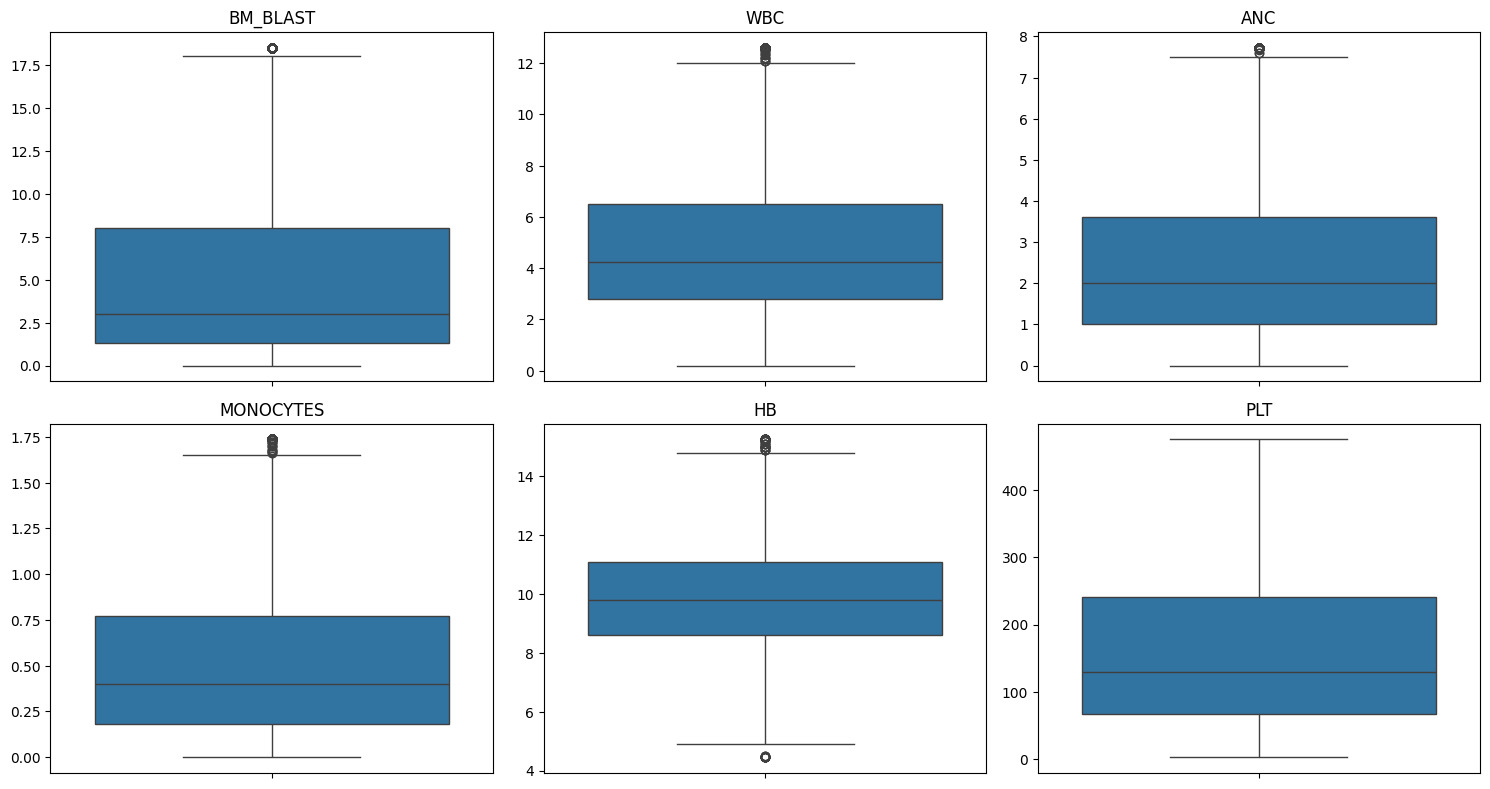

In [39]:
cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3

plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    
    plt.subplot(row,col,index + 1)
    plt.title(cl)
    sns.boxplot(df[cl])

plt.tight_layout()
plt.show()  

In [40]:
df["CENTER"].value_counts()

CENTER,count
str,u32
"""UMG""",26
"""VU""",33
"""UOB""",88
"""FUCE""",73
"""IHBT""",33
…,…
"""TUD""",73
"""KI""",900
"""RMCN""",199


# Z-SCORE

In [41]:


# cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

# for cl in cl_quantitative_var:
#     mean = df.select(pl.col(cl).mean()).item()
#     std = df.select(pl.col(cl).std()).item()

#     z_scores = df.select(((pl.col(cl) - mean) / std).alias("z"))

#     # On ajoute les Z-scores temporairement au DataFrame
#     df_with_z = df.with_columns(((pl.col(cl) - mean) / std).alias(f"z_{cl}"))

#     # Filtrer les outliers : abs(Z) > 3
#     outliers = df_with_z.filter(pl.col(f"z_{cl}").abs() > 3)
    
    
#     # Median
#     median_val = df.select(pl.col(cl).median()).item()

#     df = df.with_columns(
#         pl.when((pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound))
#         .then(median_val)
#         .otherwise(pl.col(cl))
#         .alias(cl)
#     )
    
    
#     # # Winsorisation : caper les valeurs extrêmes
#     # df = df.with_columns(
#     #     pl.when(pl.col(cl) < lower_bound).then(lower_bound)
#     #     .when(pl.col(cl) > upper_bound).then(upper_bound)
#     #     .otherwise(pl.col(cl))
#     #     .alias(cl)
#     # )

#     print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")

# ENCODING

In [42]:
df["CENTER"].value_counts() # Catecorigal => Nominal , without any order

CENTER,count
str,u32
"""IHBT""",33
"""FLO""",68
"""VU""",33
"""PV""",316
"""ROM""",104
…,…
"""RMCN""",199
"""CGM""",107
"""REL""",6


In [43]:
import category_encoders as ce

df_pd = df.to_pandas()

encoder = ce.BinaryEncoder(cols=["CENTER"])
df_encoded = encoder.fit_transform(df_pd)

df = pl.from_pandas(df_encoded)

df

# On encode avec le binary encoder car il n'intorduit pas d'ordre artificiel + n'explose pas le nombre de colonne + correct pour bcp de categories !

ID,CENTER_0,CENTER_1,CENTER_2,CENTER_3,CENTER_4,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso,is_monosomy
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64
"""P132697""",0,0,0,0,1,14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…",1.0,0.0,0.0,0.0
"""P132698""",0,0,0,0,1,1.0,7.4,2.4,0.1,11.6,42.0,"""46,xx""",0.0,0.0,0.0,0.0
"""P116889""",0,0,0,0,1,15.0,3.7,2.1,0.1,14.2,81.0,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…",0.0,0.0,0.0,0.0
"""P132699""",0,0,0,0,1,1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…",1.0,0.0,0.0,0.0
"""P132700""",0,0,0,0,1,6.0,12.6,7.725,0.9,11.1,195.0,"""46,xx,t(3;9)(p13;q22)[10]/46,x…",0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",1,0,1,1,1,1.0,3.7,2.53,0.53,8.9,476.0,"""46,xy[20]""",0.0,0.0,0.0,0.0
"""P121829""",1,0,1,1,1,0.0,4.2,2.4,0.22,10.6,49.0,"""46,xy,del(13)(q12q14)[1]/45,x,…",1.0,1.0,0.0,0.0
"""P121830""",1,0,1,1,1,0.0,1.8,0.55,0.29,9.4,86.0,"""46,xy,del(20)(q11.2q13.1)[4]/4…",1.0,0.0,0.0,1.0


In [78]:
df = df.with_columns(
    pl.when(pl.col("CYTOGENETICS").is_null())
    .then(1)
    .otherwise(0)
    .alias("Unknown_cytogenetics")
)

In [86]:
df.filter(pl.col("CYTOGENETICS").is_null())

ID,CENTER_0,CENTER_1,CENTER_2,CENTER_3,CENTER_4,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso,is_monosomy,is_a_Man,is_a_Female,Unknown_cytogenetics
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,i64,i64,i32
"""P132711""",0,0,0,0,1,15.0,1.9,0.5,0.1,10.9,158.0,null,null,null,null,null,null,null,1
"""P132713""",0,0,0,0,1,7.0,0.6,0.1,0.0,7.1,6.0,null,null,null,null,null,null,null,1
"""P106036""",0,0,0,1,0,6.0,2.1,1.2,0.26704,11.3,91.0,null,null,null,null,null,null,null,1
"""P105706""",0,0,1,0,0,3.0,9.9287,6.789,0.780404,9.4,216.0,null,null,null,null,null,null,null,1
"""P105707""",0,0,1,0,0,3.0,5.501,2.6,0.610189,11.6,358.0,null,null,null,null,null,null,null,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P118492""",1,0,0,1,0,8.0,2.79,2.1,0.1,10.8,35.0,null,null,null,null,null,null,null,1
"""P110472""",1,0,1,0,0,2.665,5.7212,2.88831,0.770489,10.25227,252.05,null,null,null,null,null,null,null,1
"""P118226""",1,0,1,0,1,2.665,5.7212,2.88831,0.770489,10.25227,252.05,null,null,null,null,null,null,null,1


In [87]:
# DETECTION DES DELETONS D'UN FRAGMENT DE CHROMOSOME

# 1 => Homme , 0 => Femme

def is_male_karyotype(karyotype, male_code='46,xy'):
    return 1 if male_code in karyotype.lower() else 0

def is_female_karyotype(karyotype, female_code='46,xx'):
    return 1 if female_code in karyotype.lower() else 0

df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x: is_male_karyotype(x))
    .alias("is_a_Man")
)

df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x: is_female_karyotype(x))
    .alias("is_a_Female")
)


C:\Users\zakar\AppData\Local\Temp\ipykernel_20208\1990037201.py:11: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(
C:\Users\zakar\AppData\Local\Temp\ipykernel_20208\1990037201.py:16: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(


In [88]:
df["is_a_Man"].value_counts()

is_a_Man,count
i64,u32
null,387
0,1315
1,1621


In [89]:
lst = df["CYTOGENETICS"].to_numpy()

for elem in lst:
    if (elem is not None):
        if ("mar" in elem):
                print(elem)

46,xy,-7,+mar[3]/46,xy[7]
47,xx,-9,+mar1,+mar2[3]/48,xx,idem,+20[16]/46,xx[1]
46,xx,del(5)(q14q34),del(8)(q21q23)[6]/44-45,xx,idem,-7,+15,-16,-19,-22,-22,+1-3mar[3]/44,xx,idem,add(17)(q25),+mar[2],+mar[2]/88-96,xx,idem*2[2]/46,xx[7]
93<4n>,xxxx,-1,-1,add(3)(p11)*2,add(5)(q31)*2,-12,add(20)(q12)*2,der(22)t(1;22)(p21;q12)*2,+r(?)*2,+mar[20]
47,xx,-4,der(5)t(5;?)(q11.2;?),del(11)(q14.1),der(20)t(1;20)(q23;p13),+2mar[13]/47,xx,-4,der(5)t(5;?)(q11.2;?),del(11)(q14.1),-20,+3mar[11]/46,xx,-4,der(5)t(5;?)q11.2;?),del(11)(q14.1),-20,+2mar[4]/46,xx[2]
46,xy,-4,-5,-7,del(12)(p11.2),-20,-22,+5mar[1]/92,xxyy,-4*2,-5*2,-7*2,del(12)(p11.2)*2,-20,*2,-22,*2,+10mar[1]/46,xy,t(5;15)(q15;p11.1)[1]/46,xy[16]
45,y,add(x)(q26),del(1)(q24),add(2)(p23),-4,del(5)(q13q31),-6,add(7)(p15),+8,del(11)(p11.2),-12,-13,+14,-15,add(17)(q23),add(19)(q13.3),+2mar[18]/46,y,add(x)(q26),-4,del(5)(q13q31),+8,-13,+mar[14]/46,xy[2]
45,xy,-5,add(15)(p11.1),-17,-21,+2mar[31]/90,xxyy,-5,-5,add(15)(p11.1)*2,-17,-17,-21,-21,+4mar[3]

In [97]:
# DETECTION DES DELETONS

import re

def contains_cyto(cytogenetic, keyword):
    return 1 if keyword in cytogenetic.lower() else 0

    
# Used for inv , del , add 
def anomaly_number(cytogenetic , keyword , regex_expr):
    if contains_cyto(cytogenetic ,keyword):
        del_nbr = re.findall(regex_expr, cytogenetic)
        if del_nbr: 
            return int(del_nbr[0])
    return -1 


# DETECTION DE TRANSLOCATION

def transloc_nbr(cytogenetic):
    if contains_cyto(cytogenetic, 't'):
        trans_nbr = re.findall(r"t\((\d+);(\d+)\)", cytogenetic)
        if trans_nbr:
            flat = [int(x) for tup in trans_nbr for x in tup]
            return flat
    return [-1]


test = df["CYTOGENETICS"][2]

print(transloc_nbr(test))

[3, 3]


In [101]:
# DELETION ANOMALY
df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x: contains_cyto(x , 'del'))
    .alias("contains_del")
)


# df = df.with_columns(
#     pl.col("CYTOGENETICS").map_elements(lambda x: anomaly_number(x,'del',regex_expr=r"del\((\d+)\)"))
#     .alias("del_chromosomes")
# )

# INVERSION ANOMALY
df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x: contains_cyto(x , 'inv'))
    .alias("contains_inv")
)


# df = df.with_columns(
#     pl.col("CYTOGENETICS").map_elements(lambda x: anomaly_number(x,'inv',regex_expr=r"inv\((\d+)\)"))
#     .alias("inversion_chromosomes")
# )

# ADDED ANOMALY
df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x: contains_cyto(x , 'add'))
    .alias("contains_add")
)


# df = df.with_columns(
#     pl.col("CYTOGENETICS").map_elements(lambda x: anomaly_number(x,'inv',regex_expr=r"add\((\d+)\)"))
#     .alias("added_chromosomes")
# )

# TRANSLOCATION ANOMALY
df = df.with_columns(
    pl.col("CYTOGENETICS").map_elements(lambda x: contains_cyto(x , 't'))
    .alias("contains_translocation")
)

# df = df.with_columns(
#     pl.col("CYTOGENETICS").map_elements(lambda x: transloc_nbr(x))
#     .alias("translocation_lst")
# )


C:\Users\zakar\AppData\Local\Temp\ipykernel_20208\1238814475.py:2: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(
C:\Users\zakar\AppData\Local\Temp\ipykernel_20208\1238814475.py:14: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(
C:\Users\zakar\AppData\Local\Temp\ipykernel_20208\1238814475.py:26: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df = df.with_columns(
C:\Users\zakar\AppData\Local\Temp\ipykernel_20208\1238814475.py:38: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to

In [119]:
for col in df.columns:
    null_count = df.select(pl.col(col).is_null().sum())[0, 0]
    if null_count > 0:
        print(f"Nom de colonne avec valeurs nulles : {col} , Nombre : {null_count}")
        df = df.with_columns(
            pl.when(pl.col(col).is_null()).then(-1).otherwise(pl.col(col)).alias(col)
        )


Nom de colonne avec valeurs nulles : CYTOGENETICS , Nombre : 387
Nom de colonne avec valeurs nulles : is_deleted_chr , Nombre : 387
Nom de colonne avec valeurs nulles : is_complex_karyo , Nombre : 387
Nom de colonne avec valeurs nulles : is_iso , Nombre : 387
Nom de colonne avec valeurs nulles : is_monosomy , Nombre : 387
Nom de colonne avec valeurs nulles : is_a_Man , Nombre : 387
Nom de colonne avec valeurs nulles : is_a_Female , Nombre : 387
Nom de colonne avec valeurs nulles : contains_del , Nombre : 387
Nom de colonne avec valeurs nulles : contains_inv , Nombre : 387
Nom de colonne avec valeurs nulles : contains_add , Nombre : 387
Nom de colonne avec valeurs nulles : contains_translocation , Nombre : 387


In [122]:
df.filter(pl.col("Unknown_cytogenetics") == 1)

ID,CENTER_0,CENTER_1,CENTER_2,CENTER_3,CENTER_4,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso,is_monosomy,is_a_Man,is_a_Female,Unknown_cytogenetics,contains_del,contains_inv,contains_add,contains_translocation,PLT_min_max,PLT_Z_score
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,i64,i64,i32,i64,i64,i64,i64,f64,f64
"""P132711""",0,0,0,0,1,15.0,1.9,0.5,0.1,10.9,158.0,"""-1""",-1.0,-1.0,-1.0,-1.0,-1,-1,1,-1,-1,-1,-1,0.329114,-0.040494
"""P132713""",0,0,0,0,1,7.0,0.6,0.1,0.0,7.1,6.0,"""-1""",-1.0,-1.0,-1.0,-1.0,-1,-1,1,-1,-1,-1,-1,0.008439,-1.279564
"""P106036""",0,0,0,1,0,6.0,2.1,1.2,0.26704,11.3,91.0,"""-1""",-1.0,-1.0,-1.0,-1.0,-1,-1,1,-1,-1,-1,-1,0.187764,-0.586663
"""P105706""",0,0,1,0,0,3.0,9.9287,6.789,0.780404,9.4,216.0,"""-1""",-1.0,-1.0,-1.0,-1.0,-1,-1,1,-1,-1,-1,-1,0.451477,0.432309
"""P105707""",0,0,1,0,0,3.0,5.501,2.6,0.610189,11.6,358.0,"""-1""",-1.0,-1.0,-1.0,-1.0,-1,-1,1,-1,-1,-1,-1,0.751055,1.589861
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P118492""",1,0,0,1,0,8.0,2.79,2.1,0.1,10.8,35.0,"""-1""",-1.0,-1.0,-1.0,-1.0,-1,-1,1,-1,-1,-1,-1,0.06962,-1.043163
"""P110472""",1,0,1,0,0,2.665,5.7212,2.88831,0.770489,10.25227,252.05,"""-1""",-1.0,-1.0,-1.0,-1.0,-1,-1,1,-1,-1,-1,-1,0.527532,0.726181
"""P118226""",1,0,1,0,1,2.665,5.7212,2.88831,0.770489,10.25227,252.05,"""-1""",-1.0,-1.0,-1.0,-1.0,-1,-1,1,-1,-1,-1,-1,0.527532,0.726181


# PLT PROCESSING

In [93]:
df["PLT"].describe()

statistic,value
str,f64
"""count""",3323.0
"""null_count""",0.0
"""mean""",162.967524
"""std""",122.672628
"""min""",2.0
"""25%""",67.0
"""50%""",129.0
"""75%""",241.0
"""max""",476.0


In [94]:
# MIN MAX Normalization

plt_min  = df["PLT"].min()
plt_max = df["PLT"].max()


df = df.with_columns(
    ((pl.col("PLT") - plt_min)/(plt_max - plt_min)).alias("PLT_min_max")
)


In [95]:
# Z-score normalization

plt_mean = df["PLT"].mean()
plt_std = df["PLT"].std()

df = df.with_columns(
    ((pl.col("PLT") - plt_mean)/(plt_std)).alias("PLT_Z_score")
)

In [96]:
df

ID,CENTER_0,CENTER_1,CENTER_2,CENTER_3,CENTER_4,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,is_deleted_chr,is_complex_karyo,is_iso,is_monosomy,is_a_Man,is_a_Female,Unknown_cytogenetics,contains_del,del_chromosomes,contains_inv,inversion_chromosomes,contains_add,added_chromosomes,contains_translocation,translocation_lst,PLT_min_max,PLT_Z_score
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,i64,i64,i32,i64,i64,i64,i64,i64,i64,i64,list[i64],f64,f64
"""P132697""",0,0,0,0,1,14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…",1.0,0.0,0.0,0.0,1,0,0,1,20,0,-1,0,-1,0,[-1],0.246835,-0.358413
"""P132698""",0,0,0,0,1,1.0,7.4,2.4,0.1,11.6,42.0,"""46,xx""",0.0,0.0,0.0,0.0,0,1,0,0,-1,0,-1,0,-1,0,[-1],0.084388,-0.9861
"""P116889""",0,0,0,0,1,15.0,3.7,2.1,0.1,14.2,81.0,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…",0.0,0.0,0.0,0.0,1,0,0,0,-1,0,-1,0,-1,1,"[3, 3]",0.166667,-0.668181
"""P132699""",0,0,0,0,1,1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…",1.0,0.0,0.0,0.0,1,0,0,1,3,0,-1,0,-1,0,[-1],0.158228,-0.700788
"""P132700""",0,0,0,0,1,6.0,12.6,7.725,0.9,11.1,195.0,"""46,xx,t(3;9)(p13;q22)[10]/46,x…",0.0,0.0,0.0,0.0,0,1,0,0,-1,0,-1,0,-1,1,"[3, 9]",0.407173,0.261122
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",1,0,1,1,1,1.0,3.7,2.53,0.53,8.9,476.0,"""46,xy[20]""",0.0,0.0,0.0,0.0,1,0,0,0,-1,0,-1,0,-1,0,[-1],1.0,2.551771
"""P121829""",1,0,1,1,1,0.0,4.2,2.4,0.22,10.6,49.0,"""46,xy,del(13)(q12q14)[1]/45,x,…",1.0,1.0,0.0,0.0,1,0,0,1,13,0,-1,0,-1,0,[-1],0.099156,-0.929038
"""P121830""",1,0,1,1,1,0.0,1.8,0.55,0.29,9.4,86.0,"""46,xy,del(20)(q11.2q13.1)[4]/4…",1.0,0.0,0.0,1.0,1,0,0,1,20,0,-1,0,-1,0,[-1],0.177215,-0.627422
